### Fjeder modellen C

In [53]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from FEM_functions import FEM_y

In [54]:

 

"""Kf = sp.Matrix([])
F_k = sp.Matrix([])

rows=[]
entry = []
def make_matrix_good(number, gamma):
    l=number
    for number in range(0,number-1):
        row= []
        for i in range(0,l-1):
            row.append(0)
        row[number+1]=2*gamma
        row[number]=2*gamma
        row[number+2]=-gamma
        rows.append(row)
    D = sp.Matrix.row_insert(Kf, 0, rows)
    print(D)
    return D

def make_vector_good(number):
    l = number
    for l in range(0,l-1):
        entry.append([1/(number+1)])
        
    D = sp.Matrix.row_insert(Kf, 0, entry)
    return D


result= sp.Matrix([[0.125],
                   [0.125],
                   [0.125],
                   [0.125],
                   [0.125],
                   [0.125],
                   [0.125]])

make_matrix_good(3,gamma)"""

'Kf = sp.Matrix([])\nF_k = sp.Matrix([])\n\nrows=[]\nentry = []\ndef make_matrix_good(number, gamma):\n    l=number\n    for number in range(0,number-1):\n        row= []\n        for i in range(0,l-1):\n            row.append(0)\n        row[number+1]=2*gamma\n        row[number]=2*gamma\n        row[number+2]=-gamma\n        rows.append(row)\n    D = sp.Matrix.row_insert(Kf, 0, rows)\n    print(D)\n    return D\n\ndef make_vector_good(number):\n    l = number\n    for l in range(0,l-1):\n        entry.append([1/(number+1)])\n\n    D = sp.Matrix.row_insert(Kf, 0, entry)\n    return D\n\n\nresult= sp.Matrix([[0.125],\n                   [0.125],\n                   [0.125],\n                   [0.125],\n                   [0.125],\n                   [0.125],\n                   [0.125]])\n\nmake_matrix_good(3,gamma)'

In [55]:
#definerer variable
N = 7
gamma = 10
h = 1 / (N + 1)

#Opstiller matricer der skal bruges til at sammensætte k_fjeder
diagonal = np.full(N, 2 * gamma)
off_diagonal = np.full(N - 1, -gamma)
#Opsitller k_fjeder
K_fjeder = np.diag(diagonal) + np.diag(off_diagonal, 1) + np.diag(off_diagonal, -1)
#Opstiller kraftfordelingsvektoren F
F = np.full(N, h)
#løser systemet Ky=F
y_indre = np.linalg.solve(K_fjeder, F)
#Viser struktur på k_fjeder
K_fjeder


array([[ 20, -10,   0,   0,   0,   0,   0],
       [-10,  20, -10,   0,   0,   0,   0],
       [  0, -10,  20, -10,   0,   0,   0],
       [  0,   0, -10,  20, -10,   0,   0],
       [  0,   0,   0, -10,  20, -10,   0],
       [  0,   0,   0,   0, -10,  20, -10],
       [  0,   0,   0,   0,   0, -10,  20]])

In [56]:
#Viser den y vektor vi finder ved at løse Ky=f
np.vstack(y_indre)

array([[0.04375],
       [0.075  ],
       [0.09375],
       [0.1    ],
       [0.09375],
       [0.075  ],
       [0.04375]])

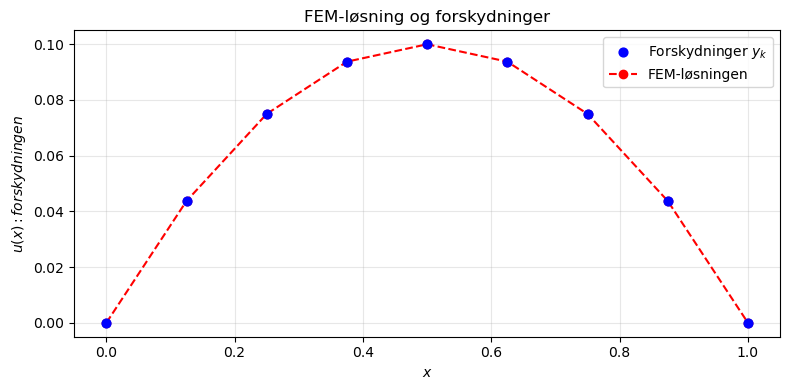

In [57]:
x_plot = np.linspace(0, 1, 500)
#x-værdien til knudepunkterne
x_knuder = np.linspace(0, 1, N + 2)
#opstiller den fulde y vektor med nul i første og sidste indgang
y_komplet = np.zeros(N + 2)
y_komplet[1:N+1] = y_indre

#opstiller graf
plt.figure(figsize=(8, 4))
plt.xlabel('$x$')
plt.ylabel('$u(x): forskydningen$')
plt.title(f'FEM-løsning og forskydninger')
plt.scatter(x_knuder, y_komplet, color='blue', s=40, label='Forskydninger $y_k$', zorder=3)
plt.plot(x_knuder, FEM_y(x_knuder, y_indre, x_knuder),'r--o', label=f'FEM-løsningen')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 